* Entrada: Lista de puntos
* distancias_minimas -> lista
* distancia_minima = INFINITO
* Para cada punto de Entrada:
* Calcular la distancia con otro punto en la lista
* Si la distancia es menor, distancia_minima = distancia_calculada
* Calcular promedio observado
* Calcular area (envelope)
* calcular distancia esperada
* Calcular indice de vecino cercano

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree, ConvexHull

In [23]:
np.random.seed(42)
grupo1 = np.random.normal(loc = [10, 10], scale = 2, size = (10, 2))
grupo2 = np.random.normal(loc = [20, 20], scale = 2, size = (10, 2))
grupo3 = np.random.normal(loc = [10, 20], scale = 2, size = (10, 2))

puntos = np.vstack([grupo1, grupo2, grupo3])
arbol = KDTree(puntos)
distancias, indices = arbol.query(puntos, k=2)

distancias_al_vecino = distancias[:, 1]
indices_al_vecino = indices[:, 1]

promedio_distancia_observada = np.mean(distancias_al_vecino)

area = ConvexHull(puntos)
area_total = area.volume
numero_puntos = len(puntos)
densidad = numero_puntos / area_total

distancia_esperada = 1 / (2 * np.sqrt(densidad))

indice_vecino_cercano = promedio_distancia_observada / distancia_esperada
print(indice_vecino_cercano)

1.1758453559866084


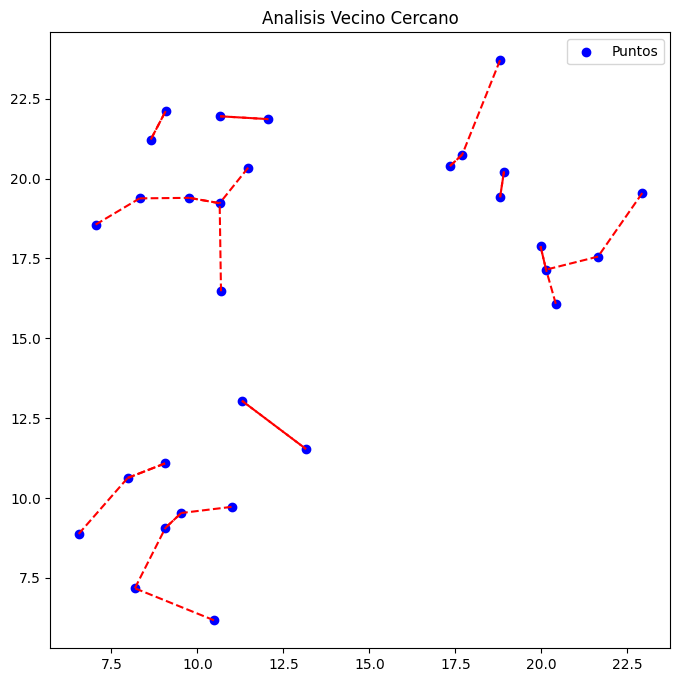

In [26]:
plt.figure(figsize=(8,8))
plt.scatter(puntos[:, 0], puntos[:, 1], c = "blue", label = "Puntos")
plt.title("Analisis Vecino Cercano")
plt.legend(["Puntos"])

for i in range(len(puntos)):
    punto_origen = puntos[i]
    vecino_idx = indices_al_vecino[i]
    punto_destino = puntos[vecino_idx]

    plt.plot([punto_origen[0], punto_destino[0]],
             [punto_origen[1], punto_destino[1]],
             color = "red", linestyle = "--")